# Transfer Learning no Dataset Paderborn (PU Dataset)

**Projeto:** Diagnóstico de Falhas em Rolamentos Industriais via CWT + Deep Learning  
**Dataset:** Paderborn University (PU Dataset — 64 kHz, Falhas Reais por Fadiga)  
**Modelos:** ResNet-18, Inception-v3 e EfficientNet-B0 (Fine-Tuning com pesos ImageNet)  
**Objetivo:** Avaliar a capacidade de generalização de redes profundas pré-treinadas na classificação de falhas reais mecânicas induzidas por desgaste acelerado.

---

## 1. Importação de Módulos e Configurações

In [2]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

from src.config import RANDOM_SEED, PADERBORN_PROCESSED_DIR, NUM_EPOCHS, LEARNING_RATE
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

from src.transfer_learning import train_and_evaluate_transfer_model
from src.visualization import plot_training_curves, plot_confusion_matrix

resultados_paderborn = {}

## 2. Experimento 1: ResNet-18 (Fine-Tuning)

[INFO] EXPERIMENTO TRANSFER LEARNING: RESNET18 | Freeze=False | Épocas=10 | LR=0.0001
Época [01/10] | Treino Loss: 0.0830 - Acc: 97.04% | Val Loss: 0.0157 - Acc: 99.46% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0090 - Acc: 99.81% | Val Loss: 0.0063 - Acc: 99.73% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0017 - Acc: 100.00% | Val Loss: 0.0009 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 03/10.
Época [04/10] | Treino Loss: 0.0015 - Acc: 100.00% | Val Loss: 0.0008 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0007 - Acc: 100.00% | Val Loss: 0.0006 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0004 - Acc: 100.00% | Val Loss: 0.0005 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 06/10.
Época [07/10] | Treino Loss: 0.0002 - Acc: 100.00% | Val Loss: 0.0004 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na 

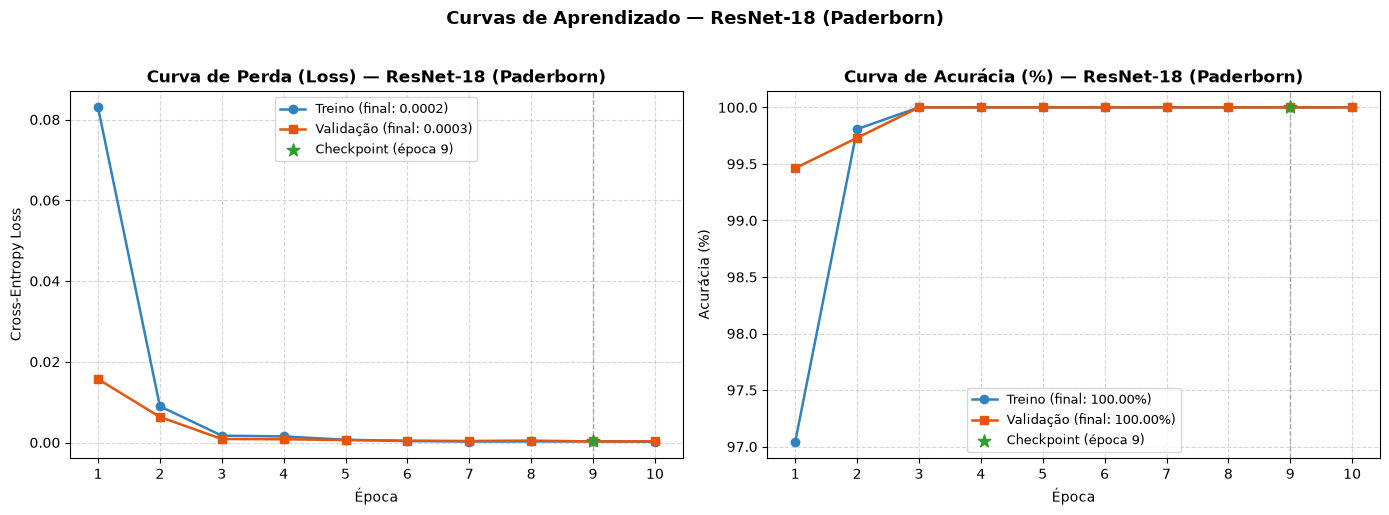

 RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (PADERBORN — RESNET-18) 
              precision    recall  f1-score   support

  inner_race     1.0000    1.0000    1.0000       248
      normal     1.0000    1.0000    1.0000       248
  outer_race     1.0000    1.0000    1.0000       248

    accuracy                         1.0000       744
   macro avg     1.0000    1.0000    1.0000       744
weighted avg     1.0000    1.0000    1.0000       744

[INFO] Figura salva em: ../docs/images/confusion_matrix_paderborn_resnet.png


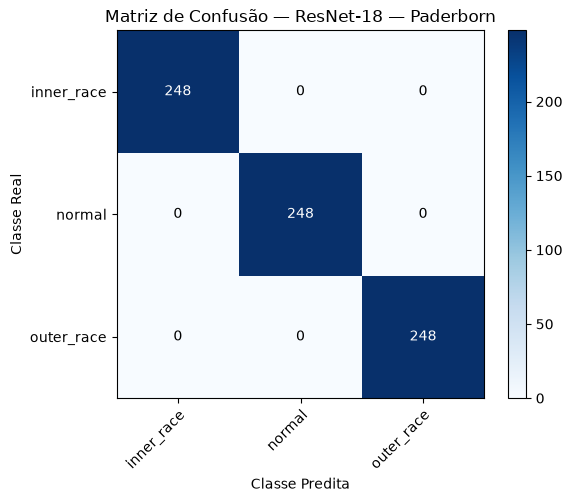

In [3]:
res_resnet = train_and_evaluate_transfer_model(
    model_name="resnet18",
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    freeze=False,
    data_dir=PADERBORN_PROCESSED_DIR,
    checkpoint_prefix="checkpoint_paderborn"
)
resultados_paderborn["resnet18"] = res_resnet

plot_training_curves(
    res_resnet['history'],
    model_name="ResNet-18 (Paderborn)",
    save_path="../docs/images/training_curves_paderborn_resnet.png"
)

print("=" * 80)
print(" RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (PADERBORN — RESNET-18) ")
print("=" * 80)
print(classification_report(
    res_resnet['test_labels'],
    res_resnet['test_preds'],
    target_names=res_resnet['classes'],
    digits=4
))

plot_confusion_matrix(
    res_resnet,
    model_name="ResNet-18 — Paderborn",
    save_path="../docs/images/confusion_matrix_paderborn_resnet.png"
)

## 3. Experimento 2: Inception-v3 (Fine-Tuning)

[INFO] EXPERIMENTO TRANSFER LEARNING: INCEPTION_V3 | Freeze=False | Épocas=10 | LR=0.0001
Época [01/10] | Treino Loss: 0.1558 - Acc: 94.89% | Val Loss: 0.0086 - Acc: 99.73% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0063 - Acc: 99.88% | Val Loss: 0.0052 - Acc: 99.73% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0049 - Acc: 99.85% | Val Loss: 0.0110 - Acc: 99.73% 
Época [04/10] | Treino Loss: 0.0019 - Acc: 100.00% | Val Loss: 0.0041 - Acc: 99.73% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0143 - Acc: 99.50% | Val Loss: 0.0089 - Acc: 99.73% 
Época [06/10] | Treino Loss: 0.0071 - Acc: 99.69% | Val Loss: 0.0065 - Acc: 99.73% 
Época [07/10] | Treino Loss: 0.0009 - Acc: 100.00% | Val Loss: 0.0004 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 07/10.
Época [08/10] | Treino Loss: 0.0006 - Acc: 100.00% | Val Loss: 0.0002 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 08/10

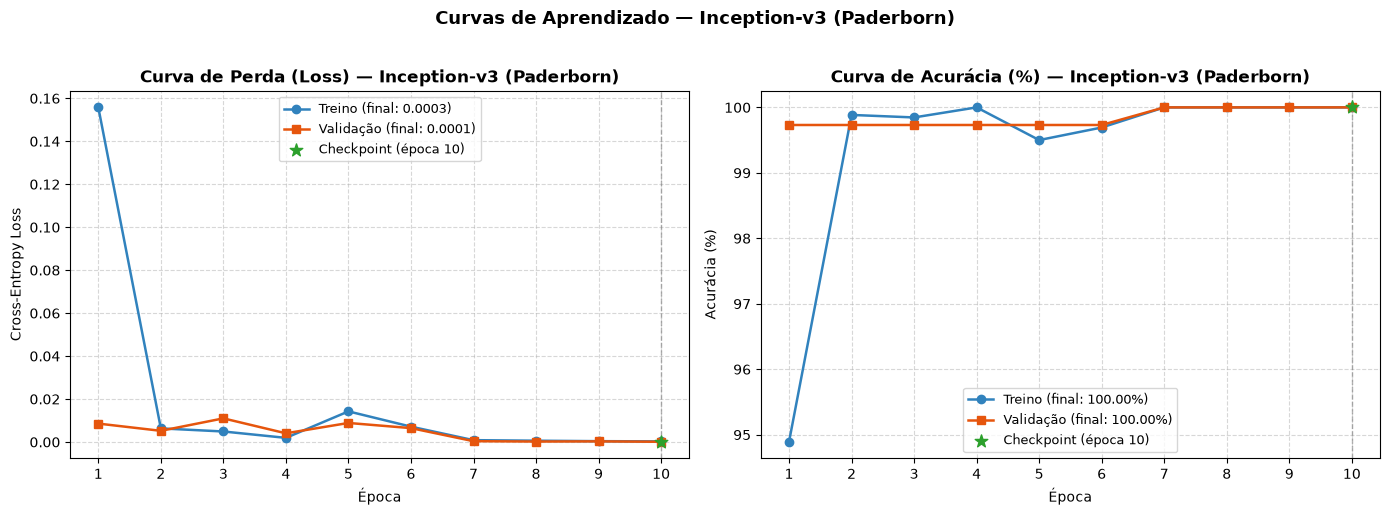

[INFO] Figura salva em: ../docs/images/confusion_matrix_paderborn_inception.png


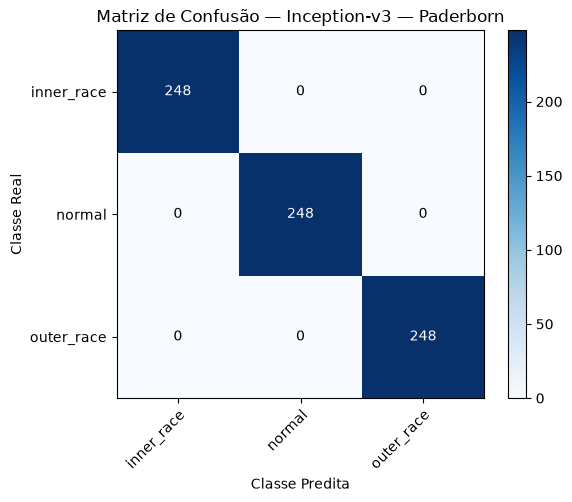

In [4]:
res_inception = train_and_evaluate_transfer_model(
    model_name="inception_v3",
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    freeze=False,
    data_dir=PADERBORN_PROCESSED_DIR,
    checkpoint_prefix="checkpoint_paderborn"
)
resultados_paderborn["inception_v3"] = res_inception

plot_training_curves(
    res_inception['history'],
    model_name="Inception-v3 (Paderborn)",
    save_path="../docs/images/training_curves_paderborn_inception.png"
)

plot_confusion_matrix(
    res_inception,
    model_name="Inception-v3 — Paderborn",
    save_path="../docs/images/confusion_matrix_paderborn_inception.png"
)

## 4. Experimento 3: EfficientNet-B0 (Fine-Tuning)

[INFO] EXPERIMENTO TRANSFER LEARNING: EFFICIENTNET_B0 | Freeze=False | Épocas=10 | LR=0.0001
Época [01/10] | Treino Loss: 0.4048 - Acc: 86.02% | Val Loss: 0.0145 - Acc: 99.73% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0252 - Acc: 99.46% | Val Loss: 0.0061 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0147 - Acc: 99.65% | Val Loss: 0.0013 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 03/10.
Época [04/10] | Treino Loss: 0.0089 - Acc: 99.81% | Val Loss: 0.0014 - Acc: 100.00% 
Época [05/10] | Treino Loss: 0.0132 - Acc: 99.65% | Val Loss: 0.0006 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0025 - Acc: 100.00% | Val Loss: 0.0007 - Acc: 100.00% 
Época [07/10] | Treino Loss: 0.0042 - Acc: 99.85% | Val Loss: 0.0004 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 07/10.
Época [08/10] | Treino Loss: 0.0019 - Acc: 99.96% | Val Loss: 0.0003 - Acc: 1

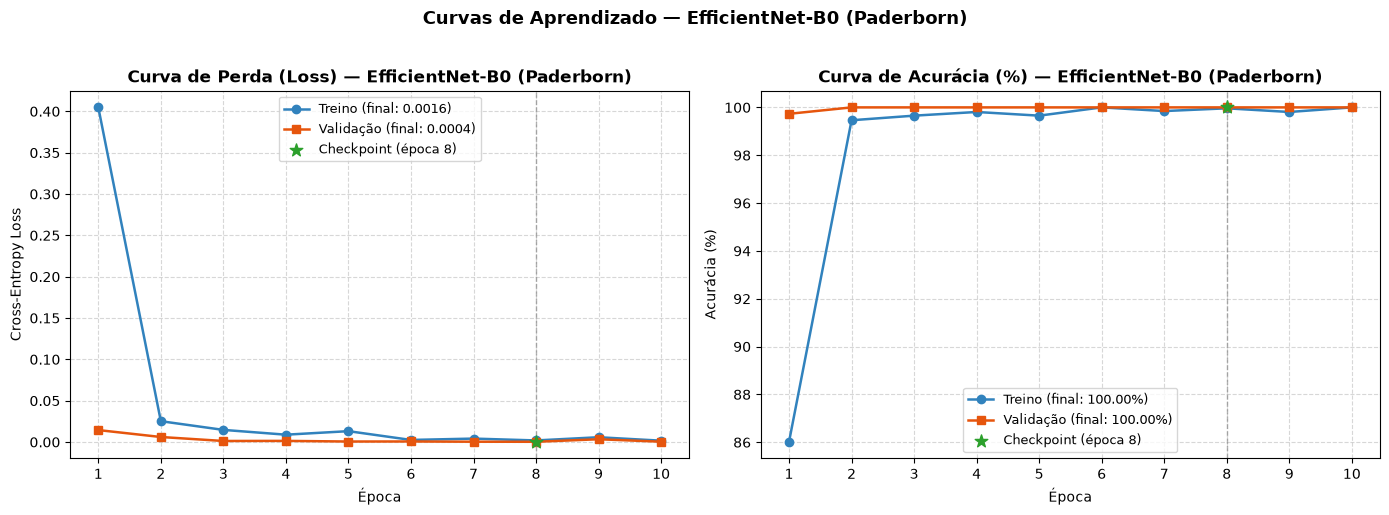

[INFO] Figura salva em: ../docs/images/confusion_matrix_paderborn_efficientnet.png


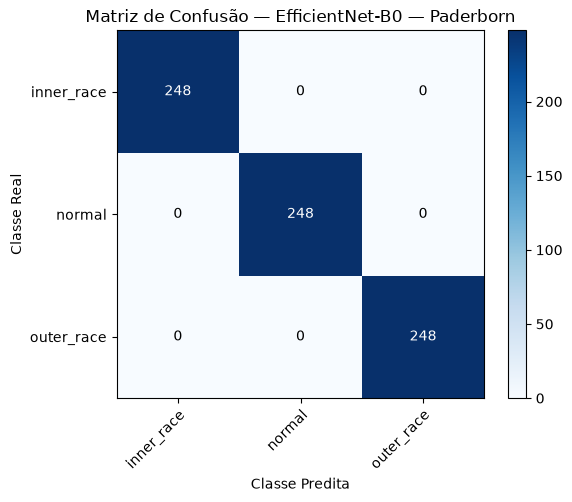

In [5]:
res_eff = train_and_evaluate_transfer_model(
    model_name="efficientnet_b0",
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    freeze=False,
    data_dir=PADERBORN_PROCESSED_DIR,
    checkpoint_prefix="checkpoint_paderborn"
)
resultados_paderborn["efficientnet_b0"] = res_eff

plot_training_curves(
    res_eff['history'],
    model_name="EfficientNet-B0 (Paderborn)",
    save_path="../docs/images/training_curves_paderborn_efficientnet.png"
)

plot_confusion_matrix(
    res_eff,
    model_name="EfficientNet-B0 — Paderborn",
    save_path="../docs/images/confusion_matrix_paderborn_efficientnet.png"
)